In [114]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [ ]:
#Load the enriched dataset
from pathlib import Path

DATA = Path("../data/processed/ethiopia_fi_enriched2.csv")

df = pd.read_csv(DATA)

df.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,%,2014-12-31,NaN,NaN,2014,all,national,NaN,Global Findex 2014,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Baseline year,NaN,2014
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,%,2017-12-31,NaN,NaN,2017,all,national,NaN,Global Findex 2017,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2017
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,all,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,NaN,NaN,2021
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,male,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,%,2021-12-31,NaN,NaN,2021,female,national,NaN,Global Findex 2021,survey,https://www.worldbank.org/en/publication/globa...,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Gender disaggregated,NaN,2021


In [116]:
#get all the events from the dataset
events = df[df["record_type"] == "event"].copy()

events[["record_id", "indicator", "category", "observation_date"]]

,record_id,indicator,category,observation_date
33,EVT_0001,Telebirr Launch,product_launch,2021-05-17
34,EVT_0002,Safaricom Ethiopia Commercial Launch,market_entry,2022-08-01
35,EVT_0003,M-Pesa Ethiopia Launch,product_launch,2023-08-01
36,EVT_0004,Fayda Digital ID Program Rollout,infrastructure,2024-01-01
37,EVT_0005,Foreign Exchange Liberalization,policy,2024-07-29
38,EVT_0006,P2P Transaction Count Surpasses ATM,milestone,2024-10-01
39,EVT_0007,M-Pesa EthSwitch Integration,partnership,2025-10-27
40,EVT_0008,EthioPay Instant Payment System Launch,infrastructure,2025-12-18
41,EVT_0009,NFIS-II Strategy Launch,policy,2021-09-01
42,EVT_0010,Safaricom Ethiopia Price Increase,pricing,2025-12-15


In [117]:
df["record_type"].value_counts()

record_type
observation    30
event          10
target          3
Name: count, dtype: int64

In [118]:
print(df["record_type"].unique())

<StringArray>
['observation', 'target', 'event']
Length: 3, dtype: str


In [119]:
impact_records = [
    {
        "record_type": "impact_link",
        "record_id": "EVT001",
        "pillar": "usage",
        "related_indicator": "ACC_MM_ACCOUNT",
        "impact_direction": "positive",
        "impact_magnitude": 0.9,
        "lag_months": 6,
        "evidence_basis": "Telebirr increased mobile money adoption."
    },
    {
        "record_type": "impact_link",
        "record_id": "EVT002",
        "pillar": "usage",
        "related_indicator": "USG_DIGITAL_PAYMENT",
        "impact_direction": "positive",
        "impact_magnitude": 0.7,updated_df = pd.concat([df, impact_df], ignore_index=True)

updated_df.tail()
        "lag_months": 12,
        "evidence_basis": "Telebirr increased digital payment usage."
    }
]

impact_df = pd.DataFrame(impact_records)
impact_df

SyntaxError: ':' expected after dictionary key (3440458360.py, line 18)

In [ ]:
#upend the new impact
updated_df = pd.concat([df, impact_df], ignore_index=True)

updated_df.tail()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
40,EVT_0008,event,infrastructure,NaN,EthioPay Instant Payment System Launch,EVT_ETHIOPAY,NaN,NaN,Launched,categorical,NaN,2025-12-18,NaN,NaN,FY2025/26,all,national,NaN,NBE/EthSwitch,regulator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National real-time payment system,NaN,2025.0
41,EVT_0009,event,policy,NaN,NFIS-II Strategy Launch,EVT_NFIS2,NaN,NaN,Launched,categorical,NaN,2021-09-01,2021-09-01,2025-06-30,2021,all,national,NaN,NBE,regulator,https://nbe.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,5-year national financial inclusion strategy,NaN,2021.0
42,EVT_0010,event,pricing,NaN,Safaricom Ethiopia Price Increase,EVT_SAFCOM_PRICE,NaN,NaN,Implemented,categorical,NaN,2025-12-15,NaN,NaN,2025,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Data and voice prices increased 20-82%,NaN,2025.0
43,EVT001,impact_link,NaN,usage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ACC_MM_ACCOUNT,NaN,positive,0.9,NaN,6.0,Telebirr increased mobile money adoption.,NaN,NaN,NaN,NaN,NaN,NaN
44,EVT002,impact_link,NaN,usage,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,USG_DIGITAL_PAYMENT,NaN,positive,0.7,NaN,12.0,Telebirr increased digital payment usage.,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
updated_df.to_csv(
    "../data/processed/ethiopia_fi_enriched2.csv",
    index=False
)

In [ ]:
#Event Categories
events["category"].value_counts()


category
product_launch    2
infrastructure    2
policy            2
market_entry      1
milestone         1
partnership       1
pricing           1
Name: count, dtype: int64

In [ ]:
print(events.shape)
events.head()

(10, 35)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
33,EVT_0001,event,product_launch,NaN,Telebirr Launch,EVT_TELEBIRR,NaN,NaN,Launched,categorical,NaN,2021-05-17,NaN,NaN,2021,all,national,NaN,Ethio Telecom,operator,https://www.ethiotelecom.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,First major mobile money service in Ethiopia,NaN,2021
34,EVT_0002,event,market_entry,NaN,Safaricom Ethiopia Commercial Launch,EVT_SAFARICOM,NaN,NaN,Launched,categorical,NaN,2022-08-01,NaN,NaN,2022,all,national,NaN,News,news,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,End of state telecom monopoly,NaN,2022
35,EVT_0003,event,product_launch,NaN,M-Pesa Ethiopia Launch,EVT_MPESA,NaN,NaN,Launched,categorical,NaN,2023-08-01,NaN,NaN,2023,all,national,NaN,Safaricom,operator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Second mobile money entrant,NaN,2023
36,EVT_0004,event,infrastructure,NaN,Fayda Digital ID Program Rollout,EVT_FAYDA,NaN,NaN,Launched,categorical,NaN,2024-01-01,NaN,NaN,2024,all,national,NaN,NIDP,regulator,https://www.id.gov.et/,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,National biometric digital ID system,NaN,2024
37,EVT_0005,event,policy,NaN,Foreign Exchange Liberalization,EVT_FX_REFORM,NaN,NaN,Implemented,categorical,NaN,2024-07-29,NaN,NaN,2024,all,national,NaN,NBE,regulator,NaN,high,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20,NaN,Birr float introduced,NaN,2024


In [ ]:
print(impact_links.shape)
print(events.shape)

(0, 35)
(10, 35)


In [ ]:
print(impact_links.columns)

Index(['record_id', 'record_type', 'category', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes', 'year'],
      dtype='str')


In [ ]:
print(events.columns)

Index(['record_id', 'record_type', 'category', 'pillar', 'indicator',
       'indicator_code', 'indicator_direction', 'value_numeric', 'value_text',
       'value_type', 'unit', 'observation_date', 'period_start', 'period_end',
       'fiscal_year', 'gender', 'location', 'region', 'source_name',
       'source_type', 'source_url', 'confidence', 'related_indicator',
       'relationship_type', 'impact_direction', 'impact_magnitude',
       'impact_estimate', 'lag_months', 'evidence_basis', 'comparable_country',
       'collected_by', 'collection_date', 'original_text', 'notes', 'year'],
      dtype='str')


In [ ]:
print(impact_links.shape)
print(events.shape)

(0, 35)
(10, 35)


In [ ]:
impact_links["record_id"].head()

Series([], Name: record_id, dtype: str)

In [ ]:
events["record_id"].head()

33    EVT_0001
34    EVT_0002
35    EVT_0003
36    EVT_0004
37    EVT_0005
Name: record_id, dtype: str

In [ ]:
print("Impact Links IDs:")
print(impact_links["record_id"].head(10))

print("\nEvents IDs:")
print(events["record_id"].head(10))

Impact Links IDs:
Series([], Name: record_id, dtype: str)

Events IDs:
33    EVT_0001
34    EVT_0002
35    EVT_0003
36    EVT_0004
37    EVT_0005
38    EVT_0006
39    EVT_0007
40    EVT_0008
41    EVT_0009
42    EVT_0010
Name: record_id, dtype: str


In [ ]:
#Explore Impact Links
impact_links.head()

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,unit,observation_date,period_start,period_end,fiscal_year,gender,location,region,source_name,source_type,source_url,confidence,related_indicator,relationship_type,impact_direction,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year


In [ ]:
#Join Events With Impact Links
event_impact = impact_links.merge(
    events,
    on="record_id",
    suffixes=("_impact","_event")
)


event_impact.head()

,record_id,record_type_impact,category_impact,pillar_impact,indicator_impact,indicator_code_impact,indicator_direction_impact,value_numeric_impact,value_text_impact,value_type_impact,unit_impact,observation_date_impact,period_start_impact,period_end_impact,fiscal_year_impact,gender_impact,location_impact,region_impact,source_name_impact,source_type_impact,source_url_impact,confidence_impact,related_indicator_impact,relationship_type_impact,impact_direction_impact,impact_magnitude_impact,impact_estimate_impact,lag_months_impact,evidence_basis_impact,comparable_country_impact,collected_by_impact,collection_date_impact,original_text_impact,notes_impact,year_impact,record_type_event,category_event,pillar_event,indicator_event,indicator_code_event,indicator_direction_event,value_numeric_event,value_text_event,value_type_event,unit_event,observation_date_event,period_start_event,period_end_event,fiscal_year_event,gender_event,location_event,region_event,source_name_event,source_type_event,source_url_event,confidence_event,related_indicator_event,relationship_type_event,impact_direction_event,impact_magnitude_event,impact_estimate_event,lag_months_event,evidence_basis_event,comparable_country_event,collected_by_event,collection_date_event,original_text_event,notes_event,year_event


In [ ]:
event_summary = event_impact[
[
"category_impact",
"related_indicator_impact",
"indicator_direction_impact",
"impact_magnitude_impact",
"lag_months_impact"
]
]


event_summary

,category_impact,related_indicator_impact,indicator_direction_impact,impact_magnitude_impact,lag_months_impact


In [ ]:
#Convert Impact Direction to Numeric
direction_map = {
    "positive":1,
    "negative":-1,
    "neutral":0
}


event_impact["direction_score"] = (
    event_impact["impact_direction_impact"]
    .map(direction_map)
)


event_impact.head()

,record_id,record_type_impact,category_impact,pillar_impact,indicator_impact,indicator_code_impact,indicator_direction_impact,value_numeric_impact,value_text_impact,value_type_impact,unit_impact,observation_date_impact,period_start_impact,period_end_impact,fiscal_year_impact,gender_impact,location_impact,region_impact,source_name_impact,source_type_impact,source_url_impact,confidence_impact,related_indicator_impact,relationship_type_impact,impact_direction_impact,impact_magnitude_impact,impact_estimate_impact,lag_months_impact,evidence_basis_impact,comparable_country_impact,collected_by_impact,collection_date_impact,original_text_impact,notes_impact,year_impact,record_type_event,category_event,pillar_event,indicator_event,indicator_code_event,indicator_direction_event,value_numeric_event,value_text_event,value_type_event,unit_event,observation_date_event,period_start_event,period_end_event,fiscal_year_event,gender_event,location_event,region_event,source_name_event,source_type_event,source_url_event,confidence_event,related_indicator_event,relationship_type_event,impact_direction_event,impact_magnitude_event,impact_estimate_event,lag_months_event,evidence_basis_event,comparable_country_event,collected_by_event,collection_date_event,original_text_event,notes_event,year_event,direction_score


In [ ]:
#Create Event-Indicator Matrix
association_matrix = event_impact.pivot_table(
    index="category_impact",
    columns="related_indicator_impact",
    values="impact_magnitude_impact",
    aggfunc="mean"
)


association_matrix

related_indicator_impact
category_impact


In [ ]:
#Save Matrix
association_matrix.to_csv(
    "../reports/event_indicator_matrix.csv"
)

In [ ]:
if association_matrix.empty:
    print("Association matrix is empty. Generate impact links first.")
else:
    plt.figure(figsize=(12, 8))

    sns.heatmap(
        association_matrix,
        annot=True,
        cmap="coolwarm",
        center=0
    )

    plt.title("Event-Indicator Association Matrix")
    plt.tight_layout()
    plt.savefig("../reports/figures/impact_heatmap.png")
    plt.show()

NameError: name 'create_impact_links' is not defined

In [ ]:
#Model Event Effect Over Time
def event_effect(
    magnitude,
    direction,
    months_after,
    lag
):
    
    if months_after < lag:
        return 0
    
    decay = np.exp(
        -(months_after-lag)/12
    )
    
    return (
        magnitude *
        direction *
        decay
    )

In [ ]:
event_impact.columns
event_impact["related_indicator_impact"].unique()

array([], dtype=float64)

In [ ]:
event_impact[
    event_impact["related_indicator_impact"].str.contains(
        "telebirr",
        case=False,
        na=False
    )
]

AttributeError: Can only use .str accessor with string values, not floating

In [ ]:
#Compare Predicted vs Observed
mm_data = observations[
observations["indicator_code"]
=="ACC_MM_ACCOUNT"
]


mm_data[
[
"observation_date",
"value_numeric"
]
]

,observation_date,value_numeric
6,2021-12-31,4.70
7,2024-11-29,9.45


In [ ]:
association_matrix.info()

<class 'pandas.DataFrame'>
Index: 0 entries
Empty DataFrame


ConversionError: Failed to convert value(s) to axis units: Timestamp('2021-05-01 00:00:00')

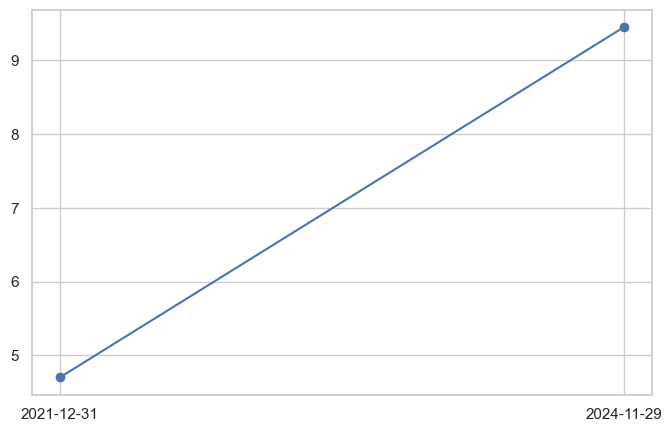

In [ ]:
#visualize the observed data
plt.figure(figsize=(8,5))


plt.plot(
mm_data["observation_date"],
mm_data["value_numeric"],
marker="o",
label="Observed"
)


plt.axvline(
pd.Timestamp("2021-05-01"),
linestyle="--",
label="Telebirr Launch"
)


plt.legend()

plt.title(
"Telebirr Event Validation"
)

plt.show()